In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("paradise_offer_raw_500_rows.csv")

# Check first 5 rows
df.head()

,customer_id,offer_taken_date,gender,age,branch_name,branch_rank,valid_upto,bill_amount,offer_usage_count,discount_amount,area_of_branch,customer_comment,food_rating,serving_rating,category,tip_amount,offer_taken
0,CUST0001,2025-01-02,M,18.0,Branch_3,3,2025-04-02,600,10,120.0,Hitech City,Not worth it :(,4.0,1.0,Veg,0,Yes
1,CUST0002,2025-01-15,NaN,30.0,Branch_9,9,2025-04-15,1200,5,0.0,Uppal,Not much benefit,5.0,3.0,Veg,1000,Yes
2,CUST0003,2025-02-14,NaN,18.0,Branch_4,4,2025-05-15,600,3,120.0,Kukatpally,good savings,4.0,1.0,VEG,1000,Yes
3,CUST0004,NaN,NaN,18.0,Branch_1,1,NaN,1200,0,50.0,Madhapur,NaN,4.0,1.0,Non veg,20,No
4,CUST0005,NaN,M,30.0,Branch_2,2,NaN,1200,0,0.0,Gachibowli,Too crowded!!!,3.0,1.0,veg,1000,No


In [2]:
# Shape of dataset
df.shape

(500, 17)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        500 non-null    object 
 1   offer_taken_date   242 non-null    object 
 2   gender             231 non-null    object 
 3   age                428 non-null    float64
 4   branch_name        500 non-null    object 
 5   branch_rank        500 non-null    int64  
 6   valid_upto         242 non-null    object 
 7   bill_amount        500 non-null    int64  
 8   offer_usage_count  500 non-null    int64  
 9   discount_amount    500 non-null    float64
 10  area_of_branch     500 non-null    object 
 11  customer_comment   441 non-null    object 
 12  food_rating        418 non-null    float64
 13  serving_rating     409 non-null    float64
 14  category           500 non-null    object 
 15  tip_amount         500 non-null    int64  
 16  offer_taken        500 non

In [4]:
df.columns

Index(['customer_id', 'offer_taken_date', 'gender', 'age', 'branch_name',
       'branch_rank', 'valid_upto', 'bill_amount', 'offer_usage_count',
       'discount_amount', 'area_of_branch', 'customer_comment', 'food_rating',
       'serving_rating', 'category', 'tip_amount', 'offer_taken'],
      dtype='object')

In [5]:
df.isnull().sum()

customer_id            0
offer_taken_date     258
gender               269
age                   72
branch_name            0
branch_rank            0
valid_upto           258
bill_amount            0
offer_usage_count      0
discount_amount        0
area_of_branch         0
customer_comment      59
food_rating           82
serving_rating        91
category               0
tip_amount             0
offer_taken            0
dtype: int64

In [6]:
df['category'].unique()

array(['Veg', 'VEG', 'Non veg', 'veg', 'Non-Veg'], dtype=object)

In [7]:
df['gender'].unique()
df['branch_name'].unique()

array(['Branch_3', 'Branch_9', 'Branch_4', 'Branch_1', 'Branch_2',
       'Branch_6', 'Branch_8', 'Branch_7', 'Branch_5', 'Branch_10'],
      dtype=object)

In [8]:
df['bill_amount'].describe()

count      500.000000
mean      2571.000000
std       3911.618657
min         50.000000
25%        300.000000
50%        900.000000
75%       3000.000000
max      12000.000000
Name: bill_amount, dtype: float64

In [9]:
df['tip_amount'].describe()
df['offer_usage_count'].describe()

count    500.000000
mean       2.778000
std        4.684507
min        0.000000
25%        0.000000
50%        0.000000
75%        3.000000
max       15.000000
Name: offer_usage_count, dtype: float64

In [10]:
# Discount given when offer not taken
df[(df['offer_taken'] == 'No') & (df['discount_amount'] > 0)].head()

,customer_id,offer_taken_date,gender,age,branch_name,branch_rank,valid_upto,bill_amount,offer_usage_count,discount_amount,area_of_branch,customer_comment,food_rating,serving_rating,category,tip_amount,offer_taken
3,CUST0004,NaN,NaN,18.0,Branch_1,1,NaN,1200,0,50.0,Madhapur,NaN,4.0,1.0,Non veg,20,No
9,CUST0010,NaN,NaN,60.0,Branch_7,7,NaN,3000,0,100.0,LB Nagar,NaN,2.0,5.0,Non-Veg,0,No
16,CUST0017,NaN,NaN,NaN,Branch_6,6,NaN,900,0,100.0,Secunderabad,good savings,2.0,2.0,Veg,20,No
30,CUST0031,NaN,NaN,30.0,Branch_4,4,NaN,600,0,100.0,Kukatpally,Loved it 😍,NaN,3.0,Non veg,50,No
32,CUST0033,NaN,NaN,5.0,Branch_8,8,NaN,300,0,100.0,Dilsukhnagar,good savings,1.0,NaN,veg,100,No


In [11]:
df_clean = df.copy()

In [12]:
df_clean['gender'] = df_clean['gender'].fillna('Unknown')
df_clean['gender'] = df_clean['gender'].replace('', 'Unknown')

In [13]:
# Convert age to numeric
df_clean['age'] = pd.to_numeric(df_clean['age'], errors='coerce')

# Calculate median age (valid range only)
median_age = df_clean[(df_clean['age'] >= 18) & (df_clean['age'] <= 80)]['age'].median()

# Replace invalid ages
df_clean.loc[(df_clean['age'] < 18) | (df_clean['age'] > 80), 'age'] = median_age
df_clean['age'] = df_clean['age'].fillna(median_age)

In [14]:
df_clean['food_rating'] = df_clean['food_rating'].fillna(df_clean['food_rating'].median())
df_clean['serving_rating'] = df_clean['serving_rating'].fillna(df_clean['serving_rating'].median())

In [15]:
df_clean['category'] = df_clean['category'].str.strip().str.lower()

df_clean['category'] = df_clean['category'].replace({
    'veg': 'Veg',
    'non veg': 'Non-Veg',
    'non-veg': 'Non-Veg'
})

In [16]:
df_clean['offer_taken'] = df_clean['offer_taken'].str.strip().str.capitalize()

In [17]:
df_clean.loc[df_clean['offer_taken'] == 'No', 'discount_amount'] = 0
df_clean.loc[df_clean['offer_taken'] == 'No', 'offer_usage_count'] = 0

In [18]:
df_clean['discount_amount'] = df_clean.apply(
    lambda x: min(x['discount_amount'], x['bill_amount'] * 0.20)
    if x['offer_taken'] == 'Yes' else 0,
    axis=1
)

In [19]:
df_clean['offer_taken_date'] = pd.to_datetime(df_clean['offer_taken_date'], errors='coerce')
df_clean['valid_upto'] = pd.to_datetime(df_clean['valid_upto'], errors='coerce')

In [20]:
upper_bill = df_clean['bill_amount'].quantile(0.99)
df_clean['bill_amount'] = df_clean['bill_amount'].clip(upper=upper_bill)

In [21]:
upper_tip = df_clean['tip_amount'].quantile(0.99)
df_clean['tip_amount'] = df_clean['tip_amount'].clip(upper=upper_tip)

In [22]:
df_clean.isnull().sum()
df_clean.describe()

,offer_taken_date,age,branch_rank,valid_upto,bill_amount,offer_usage_count,discount_amount,food_rating,serving_rating,tip_amount
count,242,500.000000,500.000000,242,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2025-02-01 15:28:15.867768576,32.974000,5.494000,2025-05-02 15:28:15.867768576,2571.000000,2.778000,237.240000,2.988000,3.000000,227.760000
min,2025-01-01 00:00:00,18.000000,1.000000,2025-04-01 00:00:00,50.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,2025-01-18 00:00:00,25.000000,3.000000,2025-04-18 00:00:00,300.000000,0.000000,0.000000,2.000000,2.000000,20.000000
50%,2025-02-03 00:00:00,30.000000,6.000000,2025-05-04 00:00:00,900.000000,0.000000,0.000000,3.000000,3.000000,50.000000
75%,2025-02-17 00:00:00,30.000000,8.000000,2025-05-18 00:00:00,3000.000000,3.000000,180.000000,4.000000,4.000000,300.000000
max,2025-03-02 00:00:00,60.000000,10.000000,2025-05-31 00:00:00,12000.000000,15.000000,2400.000000,5.000000,5.000000,1000.000000
std,NaN,12.252247,2.954899,NaN,3911.618657,4.684507,588.066345,1.281851,1.300532,345.650011


In [23]:
import pandas as pd

df = pd.read_csv("paradise_offer_cleaned.csv")

# Remove emojis from comments
df['customer_comment'] = df['customer_comment'].astype(str).str.encode('ascii', 'ignore').str.decode('ascii')

# Save as UTF-8 CSV
df.to_csv("paradise_offer_cleaned_mysql.csv", index=False, encoding='utf-8')


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("paradise_offer_cleaned.csv")

In [25]:
df['offer_taken'].value_counts()

offer_taken
No     258
Yes    242
Name: count, dtype: int64

In [26]:
df[['bill_amount', 'discount_amount']].describe()

,bill_amount,discount_amount
count,500.000000,500.000000
mean,2571.000000,237.240000
std,3911.618657,588.066345
min,50.000000,0.000000
25%,300.000000,0.000000
50%,900.000000,0.000000
75%,3000.000000,180.000000
max,12000.000000,2400.000000


In [27]:
df.groupby('offer_taken')['bill_amount'].mean()

offer_taken
No     2543.79845
Yes    2600.00000
Name: bill_amount, dtype: float64

In [28]:
offer_df = df[df['offer_taken'] == 'Yes']

total_discount = offer_df['discount_amount'].sum()
subscription_revenue = offer_df['customer_id'].nunique() * 299

total_discount, subscription_revenue

(np.float64(118620.0), 72358)

In [29]:
branch_revenue = df.groupby('branch_name')['bill_amount'].sum().sort_values(ascending=False)
branch_revenue

branch_name
Branch_1     189100
Branch_2     156900
Branch_9     145900
Branch_7     131900
Branch_6     128250
Branch_3     114850
Branch_4     114500
Branch_5     103850
Branch_8     103800
Branch_10     96450
Name: bill_amount, dtype: int64

In [30]:
df.groupby('branch_name')['offer_usage_count'].mean().sort_values(ascending=False)

branch_name
Branch_4     4.400000
Branch_1     3.490909
Branch_6     3.191489
Branch_10    2.860000
Branch_9     2.847458
Branch_8     2.645833
Branch_3     2.576923
Branch_2     2.555556
Branch_7     2.062500
Branch_5     1.319149
Name: offer_usage_count, dtype: float64

In [31]:
bins = [18,25,35,45,60,80]
labels = ['18-25','26-35','36-45','46-60','60+']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

df.groupby('age_group')['offer_usage_count'].mean()

/var/folders/8y/fp4fmdrn7rv8xcj3htynsmrr0000gn/T/ipykernel_3094/4288010338.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['offer_usage_count'].mean()


age_group
18-25    2.800000
26-35    2.895833
36-45    2.935484
46-60    3.237288
60+           NaN
Name: offer_usage_count, dtype: float64

In [32]:
df.groupby('food_rating')['offer_usage_count'].mean()

food_rating
1.0    3.712500
2.0    2.206522
3.0    2.509202
4.0    2.666667
5.0    3.160494
Name: offer_usage_count, dtype: float64

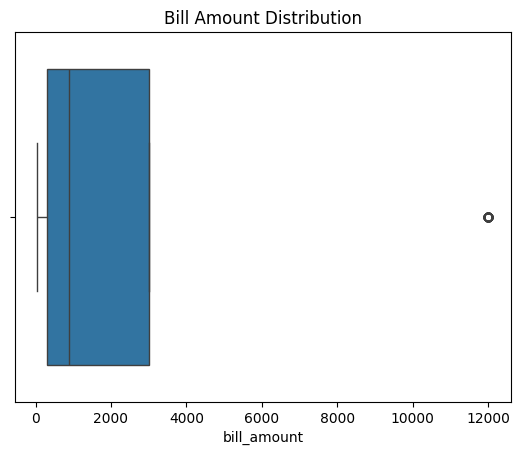

In [33]:
plt.figure()
sns.boxplot(x=df['bill_amount'])
plt.title("Bill Amount Distribution")
plt.show()

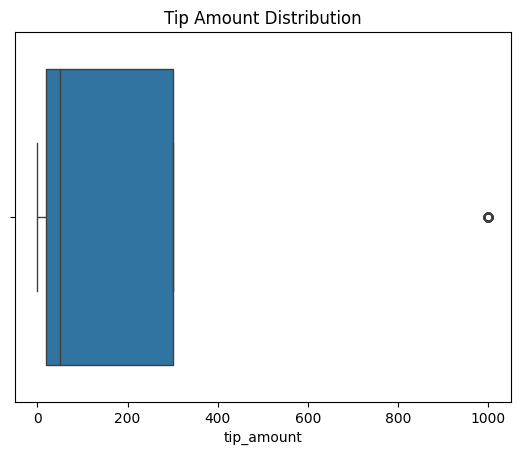

In [34]:
plt.figure()
sns.boxplot(x=df['tip_amount'])
plt.title("Tip Amount Distribution")
plt.show()

## PHASE 1: YoY / SEASON COMPARISON (PROVE OFFER IMPACT)
🎯 BUSINESS QUESTION (MOST IMPORTANT)

You already identified the correct doubt:

“Customer count & revenue increased —
but how do we know it’s because of the offer,
not because of seasonality?”

This is called:

🔥 Causal Validation / Year-over-Year (YoY) Analysis

And this is VERY HIGH-VALUE BUSINESS ANALYSIS.

In [35]:

# Load cleaned data
df = pd.read_csv("paradise_offer_cleaned_mysql.csv")

# Convert date
df['offer_taken_date'] = pd.to_datetime(df['offer_taken_date'], errors='coerce')

# Create Year column
df['year'] = df['offer_taken_date'].dt.year

df.head()

,customer_id,offer_taken_date,gender,age,branch_name,branch_rank,valid_upto,bill_amount,offer_usage_count,discount_amount,area_of_branch,customer_comment,food_rating,serving_rating,category,tip_amount,offer_taken,year
0,CUST0001,2025-01-02,M,18.0,Branch_3,3,2025-04-02,600,10,120.0,Hitech City,Not worth it :(,4.0,1.0,Veg,0,Yes,2025.0
1,CUST0002,2025-01-15,Unknown,30.0,Branch_9,9,2025-04-15,1200,5,0.0,Uppal,Not much benefit,5.0,3.0,Veg,1000,Yes,2025.0
2,CUST0003,2025-02-14,Unknown,18.0,Branch_4,4,2025-05-15,600,3,120.0,Kukatpally,good savings,4.0,1.0,Veg,1000,Yes,2025.0
3,CUST0004,NaT,Unknown,18.0,Branch_1,1,NaN,1200,0,0.0,Madhapur,NaN,4.0,1.0,Non-Veg,20,No,NaN
4,CUST0005,NaT,M,30.0,Branch_2,2,NaN,1200,0,0.0,Gachibowli,Too crowded!!!,3.0,1.0,Veg,1000,No,NaN


In [36]:
# Create last year dataset
df_2024 = df.copy()

# Change year to 2024
df_2024['year'] = 2024

# No offer last year
df_2024['offer_taken'] = 'No'
df_2024['discount_amount'] = 0
df_2024['offer_usage_count'] = 0

# Slightly reduce bill amount (simulate lower revenue)
df_2024['bill_amount'] = df_2024['bill_amount'] * 0.9

# Combine both years
df_yoy = pd.concat([df, df_2024], ignore_index=True)

df_yoy.head()

,customer_id,offer_taken_date,gender,age,branch_name,branch_rank,valid_upto,bill_amount,offer_usage_count,discount_amount,area_of_branch,customer_comment,food_rating,serving_rating,category,tip_amount,offer_taken,year
0,CUST0001,2025-01-02,M,18.0,Branch_3,3,2025-04-02,600.0,10,120.0,Hitech City,Not worth it :(,4.0,1.0,Veg,0,Yes,2025.0
1,CUST0002,2025-01-15,Unknown,30.0,Branch_9,9,2025-04-15,1200.0,5,0.0,Uppal,Not much benefit,5.0,3.0,Veg,1000,Yes,2025.0
2,CUST0003,2025-02-14,Unknown,18.0,Branch_4,4,2025-05-15,600.0,3,120.0,Kukatpally,good savings,4.0,1.0,Veg,1000,Yes,2025.0
3,CUST0004,NaT,Unknown,18.0,Branch_1,1,NaN,1200.0,0,0.0,Madhapur,NaN,4.0,1.0,Non-Veg,20,No,NaN
4,CUST0005,NaT,M,30.0,Branch_2,2,NaN,1200.0,0,0.0,Gachibowli,Too crowded!!!,3.0,1.0,Veg,1000,No,NaN


In [37]:
df_yoy.to_csv("paradise_offer_yoy.csv", index=False)

In [38]:
df_yoy.groupby('year').agg(
    total_revenue=('bill_amount', 'sum'),
    total_customers=('customer_id', 'nunique'),
    avg_bill=('bill_amount', 'mean')
)

,total_revenue,total_customers,avg_bill
year,,,
2024.0,1156950.0,500,2313.9
2025.0,629200.0,242,2600.0


In [39]:
yoy_summary = df_yoy.groupby('year').agg(
    total_revenue=('bill_amount', 'sum'),
    total_customers=('customer_id', 'nunique')
)

yoy_summary['revenue_growth_%'] = yoy_summary['total_revenue'].pct_change() * 100
yoy_summary['customer_growth_%'] = yoy_summary['total_customers'].pct_change() * 100

yoy_summary

,total_revenue,total_customers,revenue_growth_%,customer_growth_%
year,,,,
2024.0,1156950.0,500,NaN,NaN
2025.0,629200.0,242,-45.615627,-51.6


## PHASE 2: NLP SENTIMENT ANALYSIS
## (Customer Comments → Business Insight)

In [40]:
import pandas as pd

df = pd.read_csv("paradise_offer_cleaned_mysql.csv")

df[['customer_comment']].head()

,customer_comment
0,Not worth it :(
1,Not much benefit
2,good savings
3,NaN
4,Too crowded!!!


In [41]:
df['customer_comment'] = df['customer_comment'].fillna("")

In [42]:
pip install textblob

  Using cached textblob-0.19.0-py3-none-any.whl.metadata (4.4 kB)
Using cached textblob-0.19.0-py3-none-any.whl (624 kB)
Note: you may need to restart the kernel to use updated packages.


In [43]:
from textblob import TextBlob

In [44]:
def get_sentiment_score(text):
    return TextBlob(text).sentiment.polarity

df['sentiment_score'] = df['customer_comment'].apply(get_sentiment_score)

df[['customer_comment', 'sentiment_score']].head()

,customer_comment,sentiment_score
0,Not worth it :(,-0.45
1,Not much benefit,-0.10
2,good savings,0.70
3,,0.00
4,Too crowded!!!,0.00


In [45]:
def get_sentiment_label(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['sentiment_score'].apply(get_sentiment_label)

df[['customer_comment', 'sentiment', 'sentiment_score']].head()

,customer_comment,sentiment,sentiment_score
0,Not worth it :(,Negative,-0.45
1,Not much benefit,Negative,-0.10
2,good savings,Positive,0.70
3,,Neutral,0.00
4,Too crowded!!!,Neutral,0.00


In [46]:
sentiment_summary = df['sentiment'].value_counts(normalize=True) * 100
sentiment_summary

sentiment
Positive    47.4
Negative    27.8
Neutral     24.8
Name: proportion, dtype: float64

In [47]:
df.groupby('sentiment')['offer_usage_count'].mean()

sentiment
Negative    2.712230
Neutral     3.217742
Positive    2.586498
Name: offer_usage_count, dtype: float64

In [48]:
df.groupby(['branch_name', 'sentiment']).size().unstack().fillna(0)

sentiment,Negative,Neutral,Positive
branch_name,,,
Branch_1,14,19,22
Branch_10,13,9,28
Branch_2,15,12,27
Branch_3,11,15,26
Branch_4,10,7,23
Branch_5,15,13,19
Branch_6,12,14,21
Branch_7,18,8,22
Branch_8,10,8,30


In [49]:
df.to_csv("paradise_offer_with_sentiment.csv", index=False)